In [6]:
rs = 1234 
import pandas as pd
import pickle
import statsmodels.api as sm
import numpy as np
from tqdm.notebook import tqdm
tqdm.pandas()

df = pd.read_csv('cleaned_data.csv')
df.head()

,id,year,loan_limit,gender,approv_in_adv,loan_type,loan_purpose,credit_worthiness,open_credit,business_or_commercial,...,credit_type,credit_score,co-applicant_credit_type,age,submission_of_application,ltv,region,security_type,status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [7]:
#import pickled file
with open('finaldataset.pkl', 'rb') as f:
    data = pickle.load(f)

# Extract the components
X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']

Fitting Ridge Classifiers:   0%|          | 0/200 [00:00<?, ?it/s]/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:1209: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Fitting Ridge Classifiers:   0%|          | 1/200 [00:00<00:59,  3.32it/s]/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:1209: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
Fitting Ridge Classifiers:   1%|          | 2/200 [00:00<00:46,  4.26it/s]/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:1209: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y 

Top 10 most influential variables at alpha = 10000:
['lump_sum_payment_not_lpsm', 'lump_sum_payment_lpsm', 'neg_ammortization_neg_amm', 'neg_ammortization_not_neg', 'interest_rate_spread', 'upfront_charges', 'dtir1', 'submission_of_application_to_inst', 'submission_of_application_not_inst', 'occupancy_type_pr']


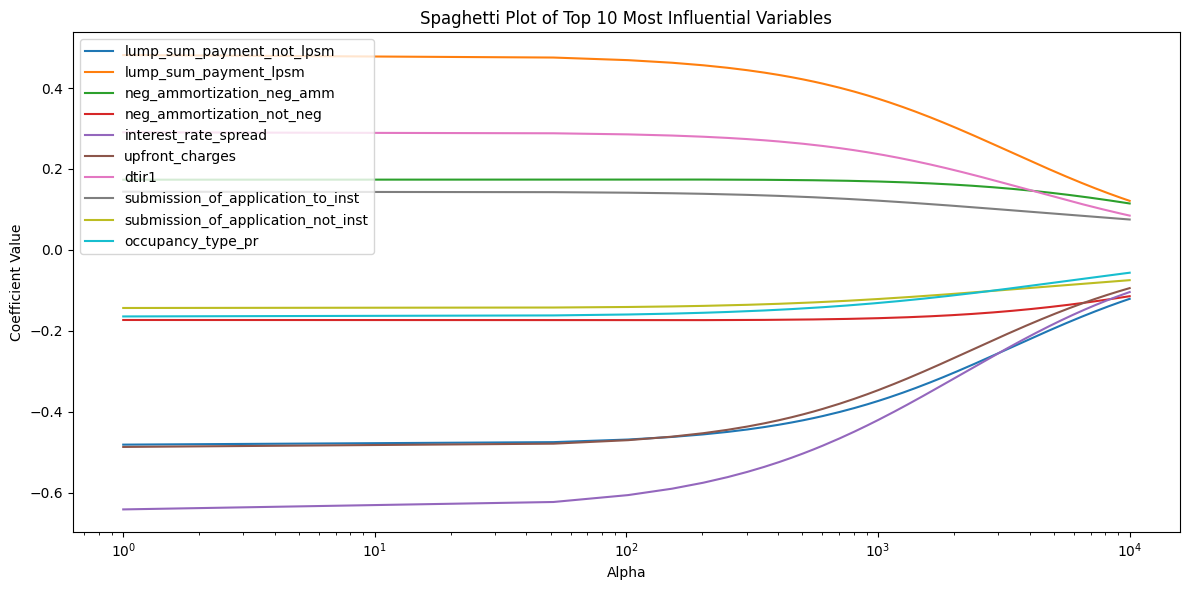

/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:1209: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


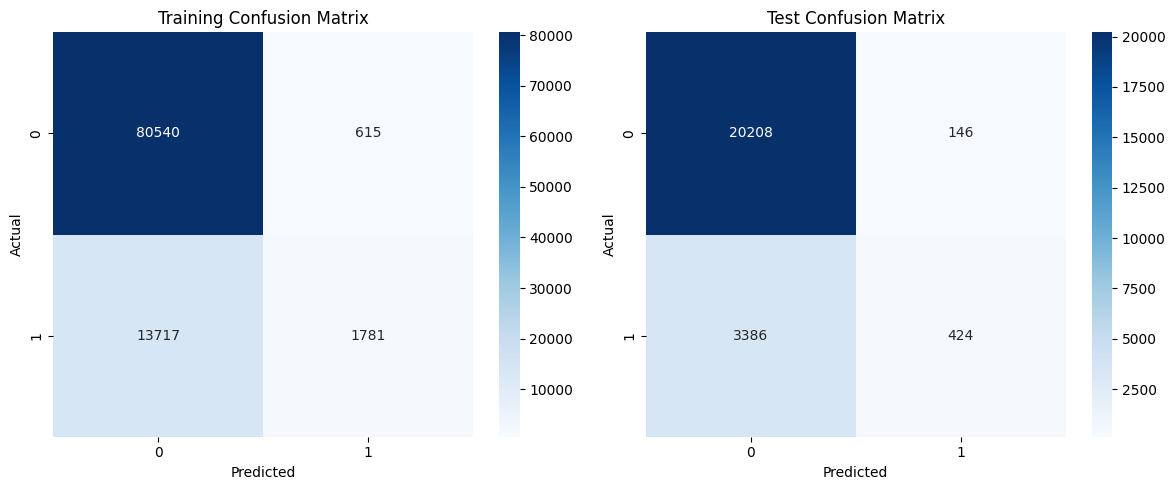

/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:1209: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


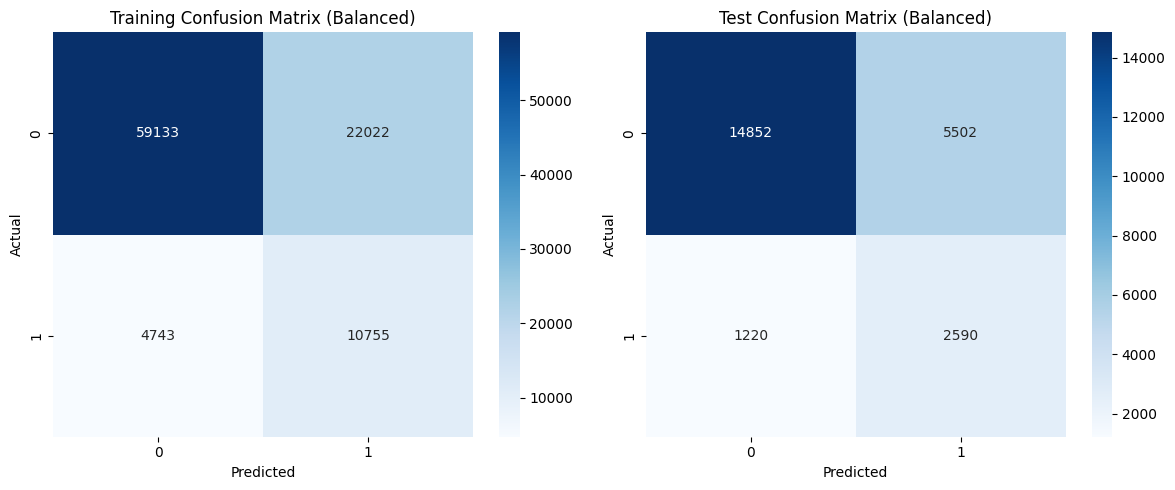

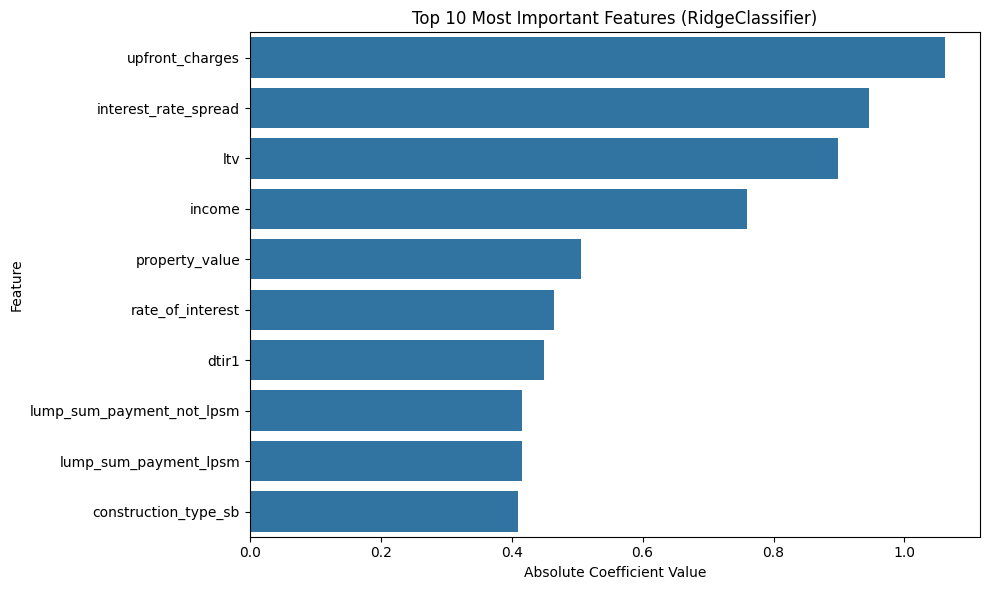

Feature Importances (Top 10):
                  Feature  Importance
          upfront_charges    1.062264
     interest_rate_spread    0.945689
                      ltv    0.899135
                   income    0.759840
           property_value    0.505255
         rate_of_interest    0.464164
                    dtir1    0.449291
lump_sum_payment_not_lpsm    0.415773
    lump_sum_payment_lpsm    0.415773
     construction_type_sb    0.410177


/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:1209: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:1209: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:1209: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:1209: DataConversionWarning: A column-vecto


CV Stats:
Accuracy - CV Avg: 0.723, Std: 0.005
Precision - CV Avg: 0.327, Std: 0.006
Recall - CV Avg: 0.692, Std: 0.016
Balanced Accuracy - CV Avg: 0.710, Std: 0.007


/opt/anaconda3/envs/misy331_base/lib/python3.13/site-packages/sklearn/linear_model/_ridge.py:1209: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [5]:
#Ridge Classification, using classiffier due to categorical variable
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, balanced_accuracy_score

# Scale data using MinMaxScaler (fit only on training set)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to DataFrame to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# 200 Ridge Classifiers for alphas 1 to 10,000
alphas = np.linspace(1, 10000, 200)
coefs = []
clf = RidgeClassifier()

# Go over each alpha value and fit RidgeClassifier
for a in tqdm(alphas, desc="Fitting Ridge Classifiers"):
    clf.set_params(alpha=a)
    clf.fit(X_train_scaled, y_train)
    coefs.append(clf.coef_[0])  # Store the coefficients of the classifier

# DataFrame of my coefficients
coefs_df = pd.DataFrame(coefs, columns=X_train.columns)

# Top 10 most influential variables at alpha = 10000 
top_10_vars = coefs_df.iloc[-1].abs().nlargest(10).index.tolist()
print("Top 10 most influential variables at alpha = 10000:")
print(top_10_vars)

# Spaghetti plot for the top 10 influential variables 
plt.figure(figsize=(12, 6))
for var in top_10_vars:
    plt.plot(alphas, coefs_df[var], label=var)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.title('Spaghetti Plot of Top 10 Most Influential Variables')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Train a RidgeClassifier with alpha = 1.0
clf = RidgeClassifier(alpha=1.0)
clf.fit(X_train_scaled, y_train)
train_pred = clf.predict(X_train_scaled)
test_pred = clf.predict(X_test_scaled)

# Confusion matrices
train_cm = confusion_matrix(y_train, train_pred)
test_cm = confusion_matrix(y_test, test_pred)

# Plot confusion matrices for training and testing sets
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(train_cm, annot=True, fmt='d', ax=ax1, cmap='Blues')
ax1.set_title('Training Confusion Matrix')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
sns.heatmap(test_cm, annot=True, fmt='d', ax=ax2, cmap='Blues')
ax2.set_title('Test Confusion Matrix')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
plt.tight_layout()
plt.show()

# Balanced RidgeClassifier to correct class imbalance
clf_balanced = RidgeClassifier(alpha=1.0, class_weight='balanced')
clf_balanced.fit(X_train_scaled, y_train)
train_pred_bal = clf_balanced.predict(X_train_scaled)
test_pred_bal = clf_balanced.predict(X_test_scaled)

# Confusion matrices for balanced classifier
train_cm_bal = confusion_matrix(y_train, train_pred_bal)
test_cm_bal = confusion_matrix(y_test, test_pred_bal)

# Plot balanced confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(train_cm_bal, annot=True, fmt='d', ax=ax1, cmap='Blues')
ax1.set_title('Training Confusion Matrix (Balanced)')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
sns.heatmap(test_cm_bal, annot=True, fmt='d', ax=ax2, cmap='Blues')
ax2.set_title('Test Confusion Matrix (Balanced)')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
plt.tight_layout()
plt.show()

# Feature importances  with plot reworked for RidgeClassifier
importances = np.abs(clf_balanced.coef_[0])  # RidgeClassifier uses coefficients, not .feature_importances_
feature_names = X_train.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values('Importance', ascending=False)  # Sort features by importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df.head(10))
plt.title('Top 10 Most Important Features (RidgeClassifier)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Display top 10 featue importances
print("Feature Importances (Top 10):")
print(feature_df.head(10).to_string(index=False))

#getting cv stats
# Define scorers
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'balanced_accuracy': make_scorer(balanced_accuracy_score)
}

# Run 10-fold cross-validation
cv_results = cross_validate(RidgeClassifier(alpha=1.0, class_weight='balanced'),
                            X_train_scaled, y_train,
                            cv=10,
                            scoring=scoring,
                            return_train_score=False)

# Print results
print("\nCV Stats:")
for metric in scoring.keys():
    mean_val = cv_results[f'test_{metric}'].mean()
    std_val = cv_results[f'test_{metric}'].std()
    print(f"{metric.replace('_', ' ').title()} - CV Avg: {mean_val:.3f}, Std: {std_val:.3f}")

# Interpretation of CV Stats:
# Accuracy - CV Avg: 0.723, Std: 0.005
# The model correctly predicted 72.3% of all loan cases across folds.
#  Accuracy can be misleading with imbalanced data such as this dataset

# Precision - CV Avg: 0.327, Std: 0.006
# When the model predicts a default (class 1), it is correct ~32.7% of the time.
# About 2 out of 3 default predictions are incorrect/ false positives

# Recall - CV Avg: 0.692, Std: 0.016
# Of all actual defaults, the model correctly catches 69.2% on average.

# Balanced Accuracy - CV Avg: 0.710, Std: 0.007
#A balanced accuracy of 71% suggests the model performs reasonably across both groups.

